### **[Backtesting Moving Averages Across Multiple Asset Classes - Part 3: EMA](https://medium.com/@alexzap922/d73cdaf52d9b)**

> *EMA Backtesting Across Asset Classes: Out-of-Sample Performance, Volatility, and Drawdowns*

In [1]:
!pip install -qq yfinance vectorbt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 451.7/451.7 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.4/300.4 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 27.8 MB/s eta 0:00:00


In [2]:
import os
import sys

import warnings
warnings.filterwarnings('ignore')

import requests
from IPython.display import display

import numpy as np
import pandas as pd

import yfinance as yf
import vectorbt as vbt

import matplotlib.pyplot as plt
from matplotlib.patches import Patch

import plotly.express as px
import plotly.graph_objects as go

IN_COLAB = 'google.colab' in sys.modules
USE_EODHD = False
USE_TWELVEDATA = False

# Set seed for reproducibility
np.random.seed(42)
np.set_printoptions(precision=4, suppress=True)

pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)
pd.set_option('display.precision', 4)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 1000)
pd.set_option('display.float_format', '{:.4f}'.format)

plt.style.use('fivethirtyeight')
plt.rcParams['figure.figsize'] = (15, 8)

%autosave 15

Autosaving every 15 seconds


In [3]:
# Tickers
tickers = ["SPY", "GLD", "BTC-USD"]

# Date range (10 years back from 2026-04-24)
end_date = "2026-04-24"
start_date = "2016-04-24"

# Download data
data = yf.download(
  tickers,
  start=start_date,
  end=end_date,
  interval="1d",
  group_by="ticker",
  auto_adjust=True,
  threads=True,
  progress=False
)

# Split into individual assets
spy = data["SPY"]
gld = data["GLD"]
btc = data["BTC-USD"]

spy_yf = spy
gld_yf = gld
btc_yf = btc

close = pd.DataFrame({
  "SPY": spy["Close"],
  "GLD": gld["Close"],
  "BTC": btc["Close"]
})
close = close.dropna()


display(close.tail(10))

,SPY,GLD,BTC
Date,,,
2026-04-10,679.4600,437.1300,72979.0469
2026-04-13,686.1000,435.3600,74484.6406
2026-04-14,694.4600,445.0900,74181.6094
2026-04-15,699.9400,440.4600,74805.0781
2026-04-16,701.6600,440.0800,75152.1328
2026-04-17,710.1400,445.9300,77126.8750
2026-04-20,708.7200,442.0900,75872.5234
2026-04-21,704.0800,429.5700,76352.7734
2026-04-22,711.2100,435.2600,78203.1016


#### **EOD HD API**

In [4]:
def get_eodhd_data(symbol, exchange):
  EODHD_API_KEY = os.getenv("EODHD_API_KEY", None)
  url = f"https://eodhistoricaldata.com/api/eod/{symbol}.{exchange}"

  params = {
    "api_token": EODHD_API_KEY,
    "period": "d",
    "from": "2016-04-24",
    "to": "2026-04-24",
    "fmt": "json"
  }

  r = requests.get(url, params=params)
  data = r.json()

  df = pd.DataFrame(data)
  df["date"] = pd.to_datetime(df["date"])
  df = df.set_index("date").sort_index()

  return df

if USE_EODHD:
  spy = get_eodhd_data("SPY", "US")
  gld = get_eodhd_data("GLD", "US")
  btc = get_eodhd_data("BTC-USD", "CC")

  spy_eod = spy
  gld_eod = gld
  btc_eod = btc

  close = pd.DataFrame({
    "SPY": spy["close"],
    "GLD": gld["close"],
    "BTC": btc["close"]
  })

  # Create a single DataFrame of closing prices for multiple assets and remove missing values.
  close = close.dropna()

  display(close.tail())

#### **TwelveData API**

In [5]:
def get_twelvedata(symbol):
  if USE_TWELVEDATA:
    TD_API_KEY = os.getenv("TWELVEDATA_API_KEY", None)
  url = "https://api.twelvedata.com/time_series"

  params = {
    "symbol": symbol,
    "interval": "1day",
    "start_date": "2016-04-24",
    "end_date": "2026-04-24",
    "apikey": TD_API_KEY,
    "format": "JSON",
    "outputsize": 5000
  }

  r = requests.get(url, params=params)
  data = r.json()

  df = pd.DataFrame(data["values"])

  # Convert types
  df["datetime"] = pd.to_datetime(df["datetime"])
  df = df.set_index("datetime").sort_index()

  if "volume" in df.columns:
    df["volume"] = pd.to_numeric(df["volume"], errors="coerce")
  else:
    df["volume"] = None

  for col in ["open", "high", "low", "close", "volume"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

  return df

if USE_TWELVEDATA:
  spy = get_twelvedata("SPY")
  gld = get_twelvedata("GLD")
  btc = get_twelvedata("BTC/USD:Binance")

  spy_td = spy
  gld_td = gld
  btc_td = btc

  close = pd.DataFrame({
    "SPY": spy["close"],
    "GLD": gld["close"],
    "BTC": btc["close"]
  })

  close = close.dropna()

  display(close.tail())

#### **VectorBT's Yahoo Finance**

#### **SPY**

In [6]:
start_date = "2016-04-24"
end_date = "2026-04-24"

symbols = "SPY"
yfdata = vbt.YFData.download(symbols, start=start_date, end=end_date)

data = yfdata.data['SPY']

fig = go.Figure(data=[
  go.Candlestick(
    x=data.index,
    open=data['Open'],
    high=data['High'],
    low=data['Low'],
    close=data['Close']
  )
])

# remove range slider + set labels + title
fig.update_layout(
  xaxis_rangeslider_visible=False,
  xaxis_title="Date",
  yaxis_title="Price USD",
  title="SPY OHLC"
)

fig.show()

In [7]:
price = yfdata.data['SPY'].vbt
price.ohlcv.plot().show()

#### **GLD**

In [8]:
symbols = "GLD"
yfdata = vbt.YFData.download(symbols,start=start_date, end=end_date)

fig = go.Figure(data=[
  go.Candlestick(
    x=data.index,
    open=data['Open'],
    high=data['High'],
    low=data['Low'],
    close=data['Close']
  )
])

# remove range slider + set labels + title
fig.update_layout(
  xaxis_rangeslider_visible=False,
  xaxis_title="Date",
  yaxis_title="Price USD",
  title="GLD OHLC"
)

fig.show()

In [9]:
price = yfdata.data['GLD'].vbt
price.ohlcv.plot().show()

#### **BTC-USD**

In [10]:
symbols = "BTC-USD"
yfdata = vbt.YFData.download(symbols,start=start_date, end=end_date)

data = yfdata.data['BTC-USD']

fig = go.Figure(data=[
  go.Candlestick(
    x=data.index,
    open=data['Open'],
    high=data['High'],
    low=data['Low'],
    close=data['Close']
  )
])

# remove range slider + set labels + title
fig.update_layout(
  xaxis_rangeslider_visible=False,
  xaxis_title="Date",
  yaxis_title="Price USD",
  title="BTC-USD OHLC"
)

fig.show()

In [11]:
price = yfdata.data['BTC-USD'].vbt
price.ohlcv.plot().show()

#### **EMA Crossover Trend-Following Strategy**

In [12]:
# --- Our input (already prepared) ---
# close = pd.DataFrame({
#     "SPY": spy["close"],
#     "GLD": gld["close"],
#     "BTC": btc["close"]
# }).dropna()

# --- Two EMA hyperparameters ---
# Defined e.g. during manual optimization
fast_span = 10
slow_span = 100

#A classic trend-following setup
#with two exponential moving averages (EMAs):
#Fast EMA (reacts quickly to price changes)
#Slow EMA (reacts slowly)

# --- 1. Compute EMAs ---
ema_fast = close.ewm(span=fast_span, adjust=False).mean()
ema_slow = close.ewm(span=slow_span, adjust=False).mean()

#For each asset: ema_fast = short-term trend  & ema_slow = long-term trend

# --- 2. Generate signals (per asset) ---
signal = (ema_fast > ema_slow).astype(int)

#If fast EMA > slow EMA = 1 (BUY / hold long) Else = 0 (NO position)
# So it's a simple trend filter.

# Shift to avoid lookahead bias (trade next day)
signal = signal.shift(1).fillna(0) #shifts signals by 1 day to avoid lookahead bias
#We trade based on yesterday’s signal, not today’s future knowledge


# --- 3. Compute returns ---
returns = close.pct_change().fillna(0) #converts price changes into daily returns

# --- 4. Strategy returns per asset ---

#the strategy only participates in upward trends.
#If signal = 1 earn the asset return
#If signal = 0 earn nothing (cash)

strategy_returns = signal * returns

# --- 5. Equity curves per asset ---

#converts returns into growth of $1 over time

equity_curves = (1 + strategy_returns).cumprod()

# --- 6. Buy & Hold benchmark ---
buy_hold = (1 + returns).cumprod()

# --- 7. Summary stats function ---
# computes standard trading metrics assuming 252 trading days/year
def performance_stats(ret):
  ann_ret = (1 + ret.mean())**252 - 1
  ann_vol = ret.std() * np.sqrt(252) #risk (how noisy returns are)
  sharpe = ann_ret / ann_vol if ann_vol != 0 else np.nan #Higher means better return per unit risk
  max_dd = (ret.add(1).cumprod() / ret.add(1).cumprod().cummax() - 1).min() # worst peak-to-trough loss
  return pd.Series({
    "Annual Return": ann_ret,
    "Annual Vol": ann_vol,
    "Sharpe": sharpe,
    "Max Drawdown": max_dd
  })

# --- 8. Compute stats per asset ---
stats = pd.concat(
    {col: performance_stats(strategy_returns[col]) for col in close.columns},
    axis=1
).T

# --- 9. Compare with Buy & Hold ---
bh_stats = pd.concat(
    {col: performance_stats(returns[col]) for col in close.columns},
    axis=1
).T

print("Strategy Stats:\n")
display(stats)

print("\nBuy & Hold Stats:\n")
display(bh_stats)

Strategy Stats:



,Annual Return,Annual Vol,Sharpe,Max Drawdown
SPY,0.1152,0.1157,0.9964,-0.2088
GLD,0.1082,0.1425,0.7591,-0.2189
BTC,0.9149,0.5337,1.7140,-0.7277



Buy & Hold Stats:



,Annual Return,Annual Vol,Sharpe,Max Drawdown
SPY,0.1677,0.1794,0.9348,-0.3372
GLD,0.1530,0.1591,0.9614,-0.2200
BTC,1.0935,0.6694,1.6335,-0.8304


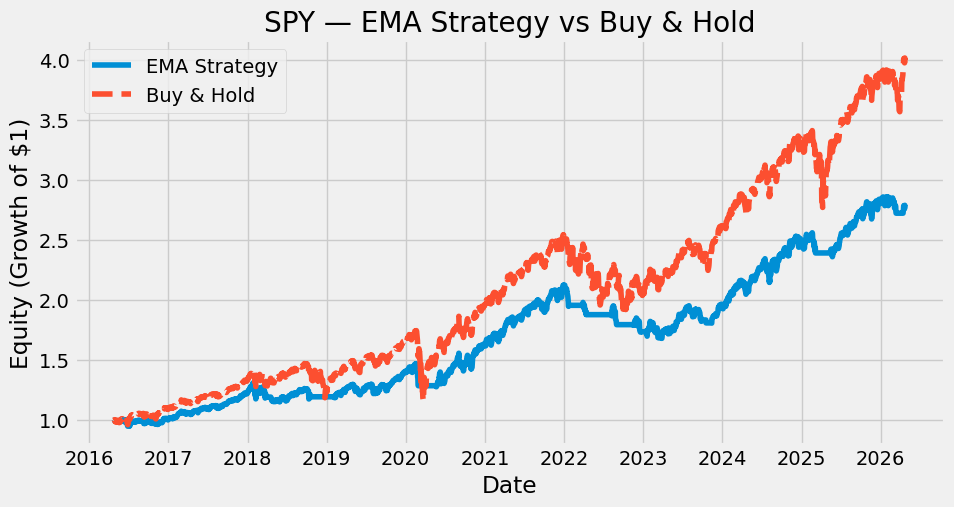

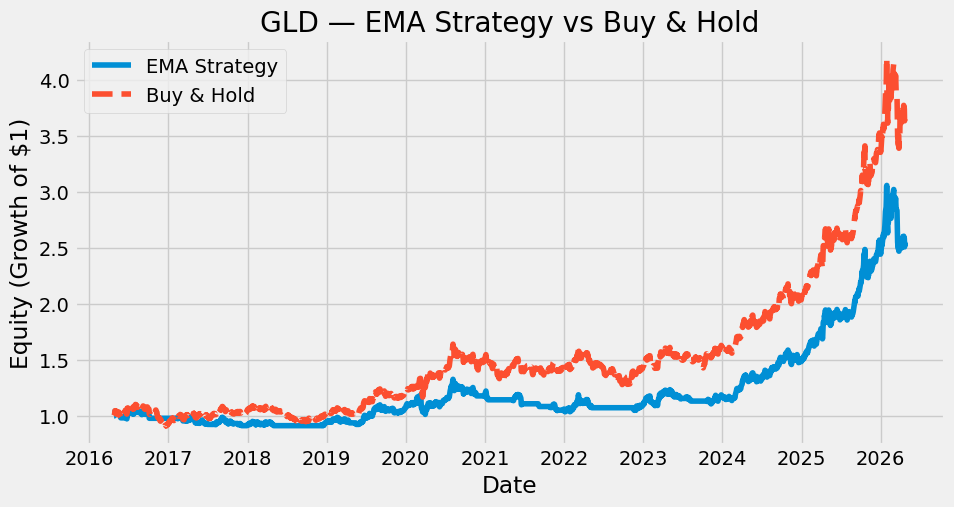

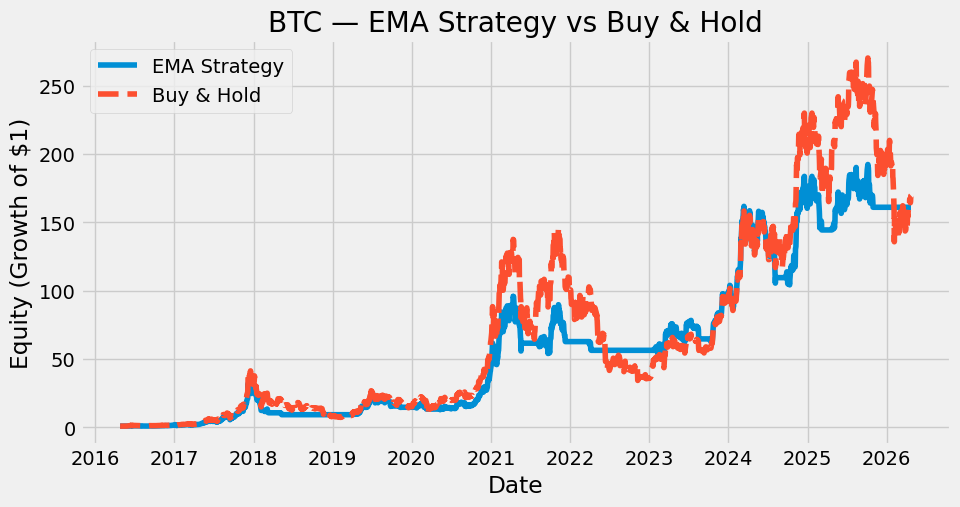

In [13]:
for col in close.columns:
  plt.figure(figsize=(10, 5))

  plt.plot(equity_curves.index, equity_curves[col], label="EMA Strategy") #how our strategy grow
  plt.plot(buy_hold.index, buy_hold[col], label="Buy & Hold", linestyle="--") #how simply holding the asset grows

  plt.title(f"{col} — EMA Strategy vs Buy & Hold")
  plt.xlabel("Date")
  plt.ylabel("Equity (Growth of $1)")
  plt.legend()
  plt.grid(True)

  plt.show()

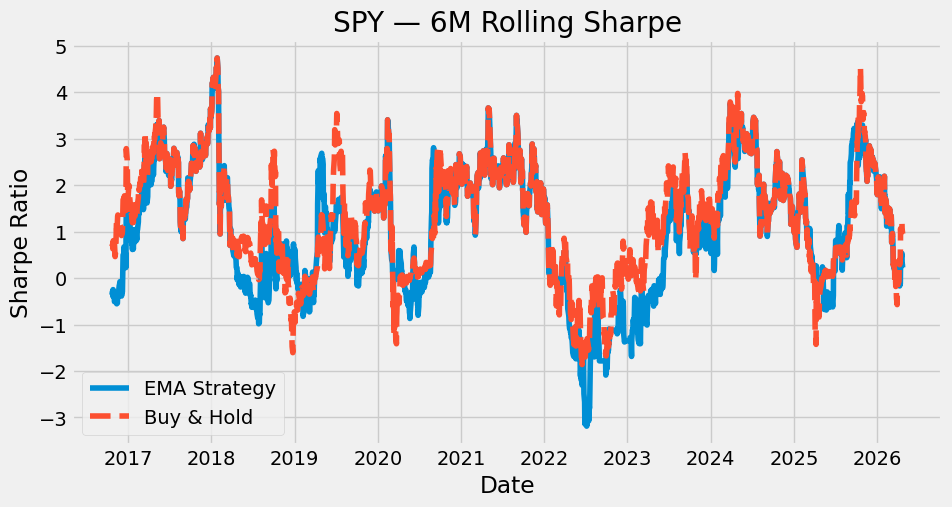

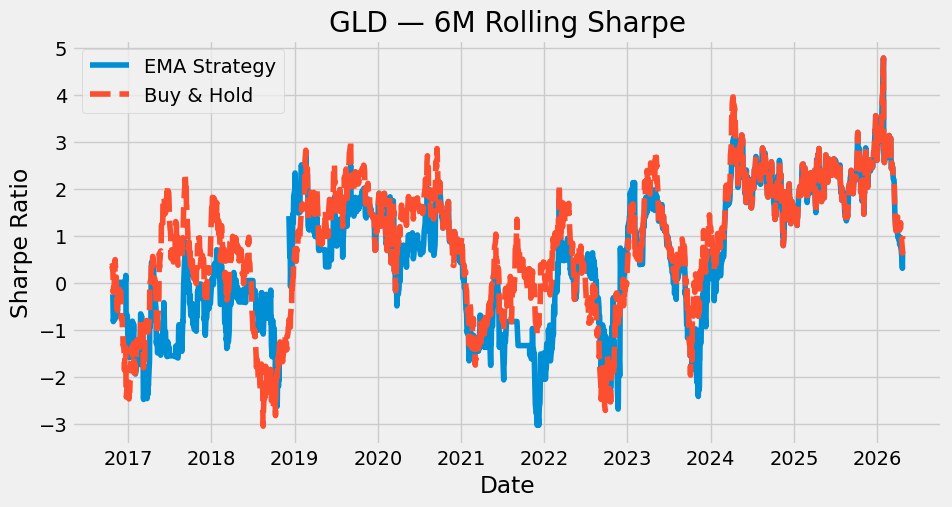

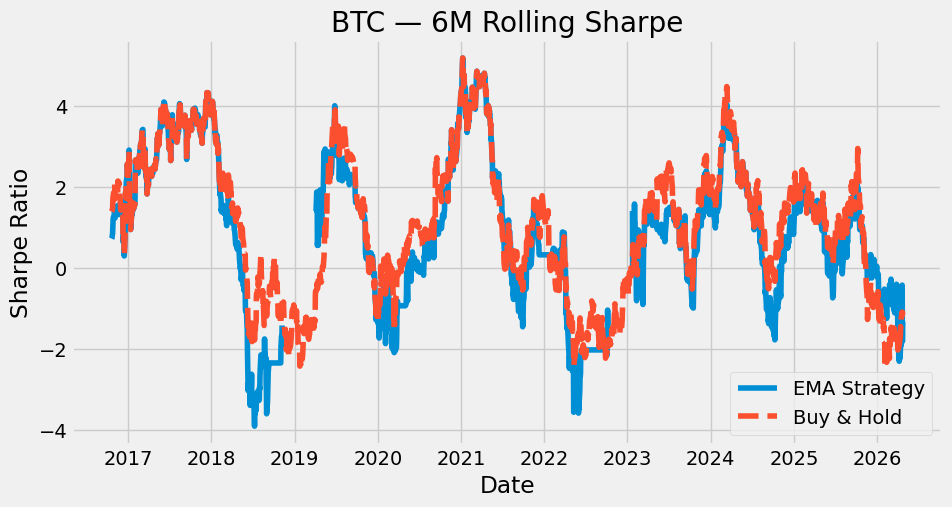

In [14]:
# --- Parameters ---
window = 126  # ~6 months of trading days

# --- Rolling Sharpe function ---
def rolling_sharpe(returns, window):
  roll_mean = returns.rolling(window).mean()
  roll_std = returns.rolling(window).std()
  sharpe = (roll_mean / roll_std) * np.sqrt(252)
  return sharpe

# --- Compute rolling Sharpe ---
rolling_sharpe_strategy = strategy_returns.apply(lambda x: rolling_sharpe(x, window))
rolling_sharpe_bh = returns.apply(lambda x: rolling_sharpe(x, window))

# --- Plot per asset ---
for col in close.columns:
  plt.figure(figsize=(10, 5))

  plt.plot(rolling_sharpe_strategy.index, rolling_sharpe_strategy[col],
            label="EMA Strategy")
  plt.plot(rolling_sharpe_bh.index, rolling_sharpe_bh[col],
            label="Buy & Hold", linestyle="--")

  #plt.axhline(0)  # zero Sharpe reference

  plt.title(f"{col} — 6M Rolling Sharpe")
  plt.xlabel("Date")
  plt.ylabel("Sharpe Ratio")
  plt.legend()
  plt.grid(True)

  plt.show()

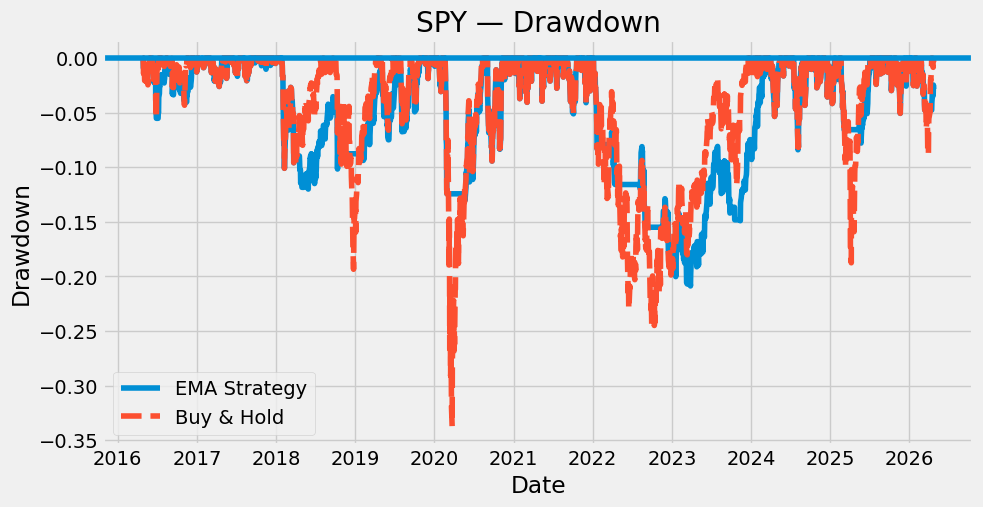

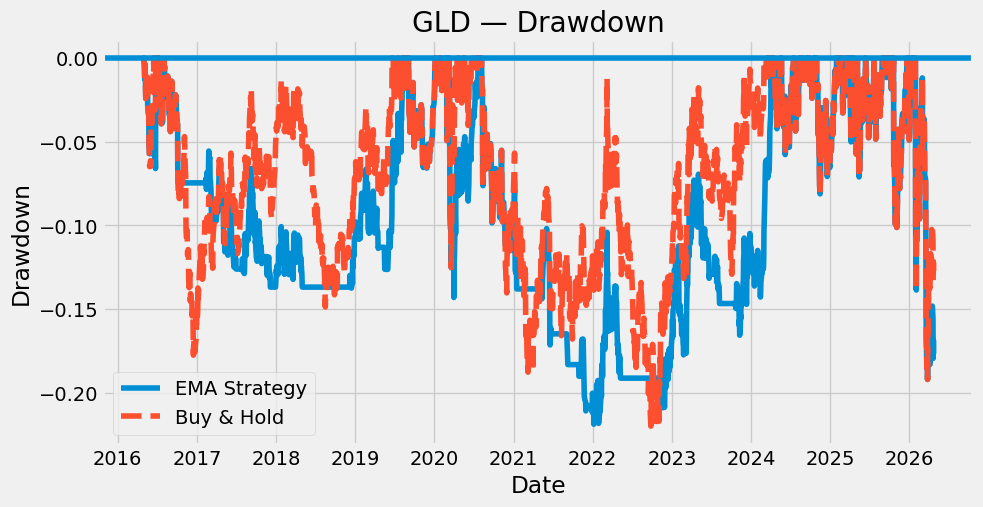

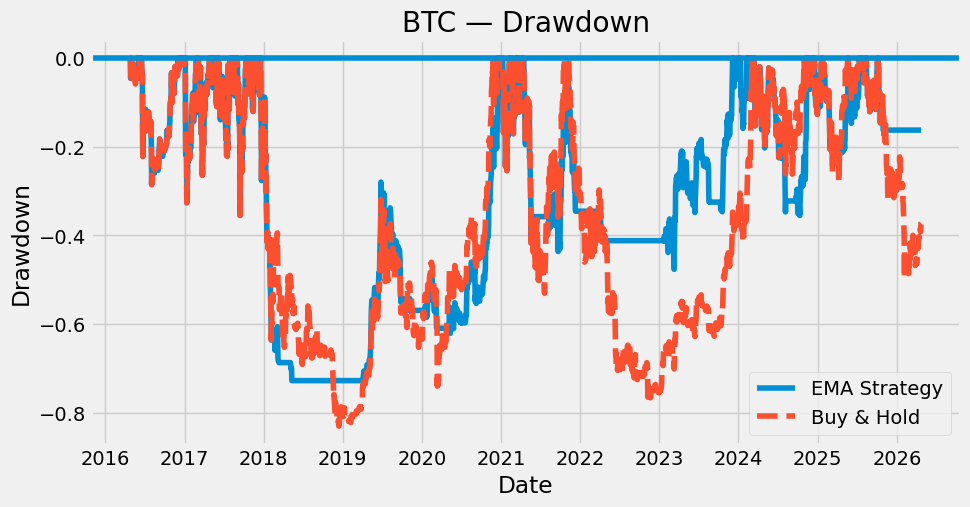

In [15]:
# --- Drawdown function ---
def drawdown(equity):
  peak = equity.cummax()
  dd = (equity / peak) - 1
  return dd

# --- Compute drawdowns ---
dd_strategy = equity_curves.apply(drawdown)
dd_bh = buy_hold.apply(drawdown)

for col in close.columns:
  plt.figure(figsize=(10, 5))

  plt.plot(dd_strategy.index, dd_strategy[col], label="EMA Strategy")
  plt.plot(dd_bh.index, dd_bh[col], label="Buy & Hold", linestyle="--")

  plt.axhline(0)  # peak line

  plt.title(f"{col} — Drawdown")
  plt.xlabel("Date")
  plt.ylabel("Drawdown")
  plt.legend()
  plt.grid(True)

  plt.show()

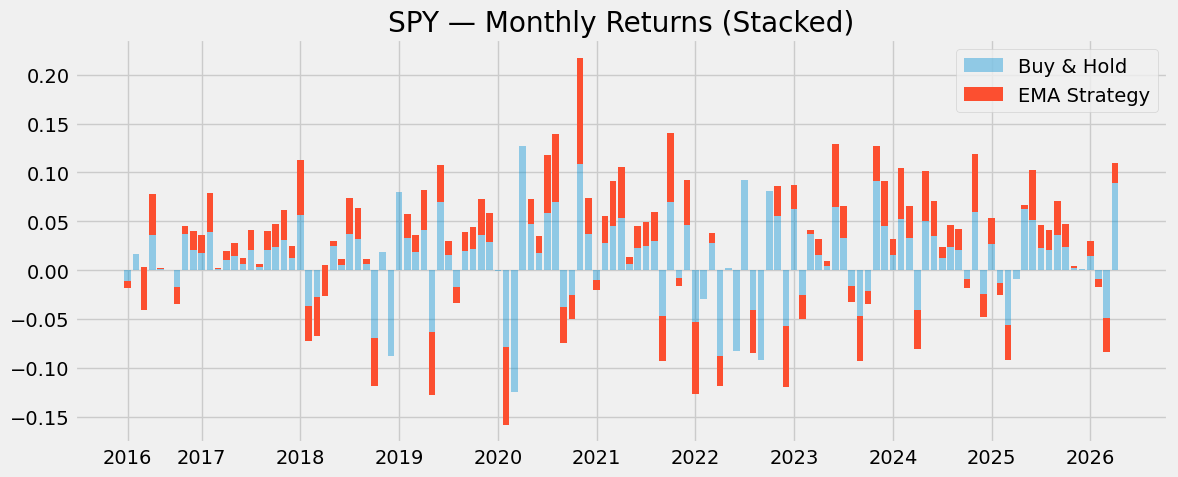

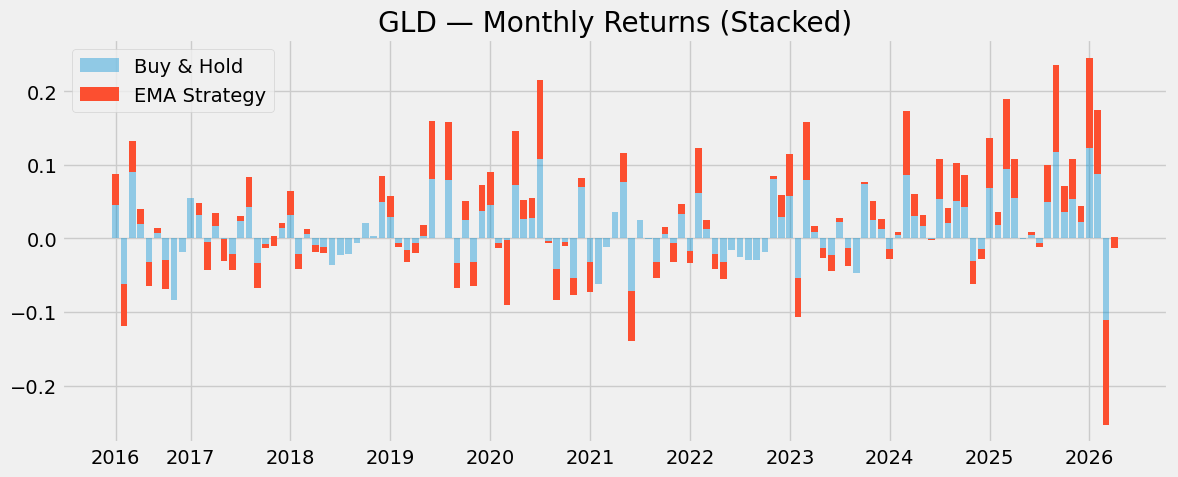

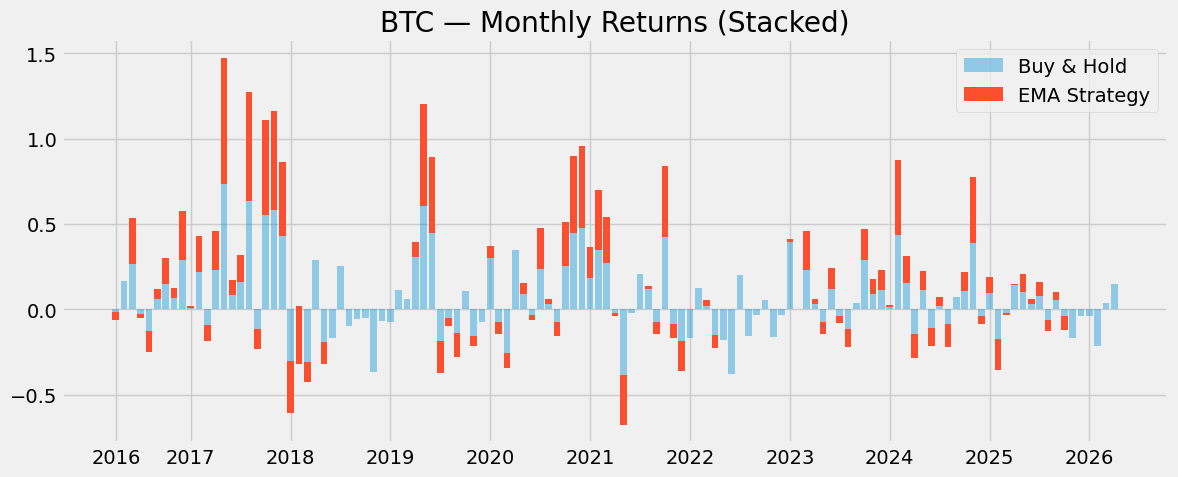

In [16]:
monthly_returns = close.resample("M").last().pct_change().dropna()

strategy_returns = strategy_returns.fillna(0)

# Strategy monthly returns
strategy_monthly = (1 + strategy_returns).resample("M").prod() - 1

# Calculate Buy & Hold monthly returns
monthly_bh = (1 + returns).resample("M").prod() - 1

# Assign strategy_monthly to monthly_strat for plotting consistency
monthly_strat = strategy_monthly

for col in close.columns:
  fig, ax = plt.subplots(figsize=(12, 5))

  bh = monthly_bh[col]
  strat = monthly_strat[col]

  # --- Align indices (THIS FIXES YOUR ERROR) ---
  data = pd.concat([bh, strat], axis=1).dropna()
  data.columns = ["bh", "strat"]

  # --- Stacked bars ---
  ax.bar(data.index.astype(str), data["bh"].values, label="Buy & Hold",alpha=0.4)
  ax.bar(data.index.astype(str), data["strat"].values,
          bottom=data["bh"].values, label="EMA Strategy")

  ax.set_title(f"{col} — Monthly Returns (Stacked)")
  ax.legend()

  # --- Yearly ticks ---
  years = data.index.year
  unique_years = np.unique(years)
  tick_positions = [np.where(years == y)[0][0] for y in unique_years]

  ax.set_xticks(tick_positions)
  ax.set_xticklabels(unique_years, rotation=0)

  ax.grid(True)
  plt.tight_layout()
  plt.show()

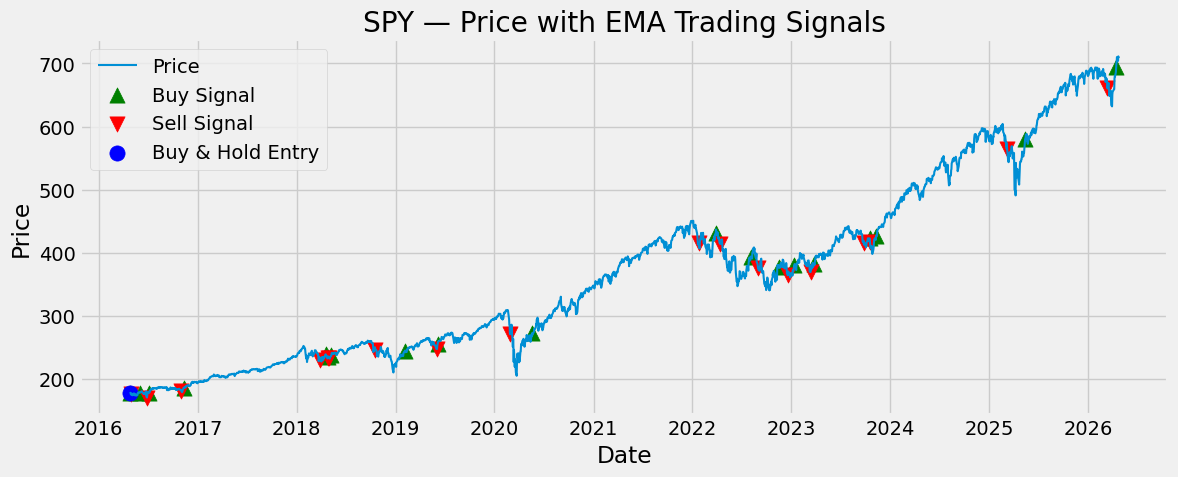

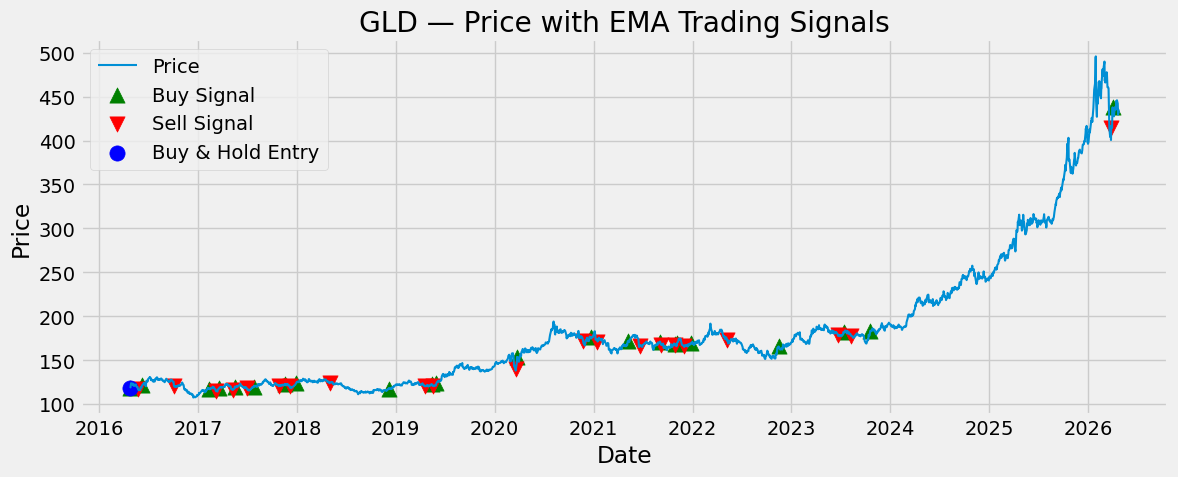

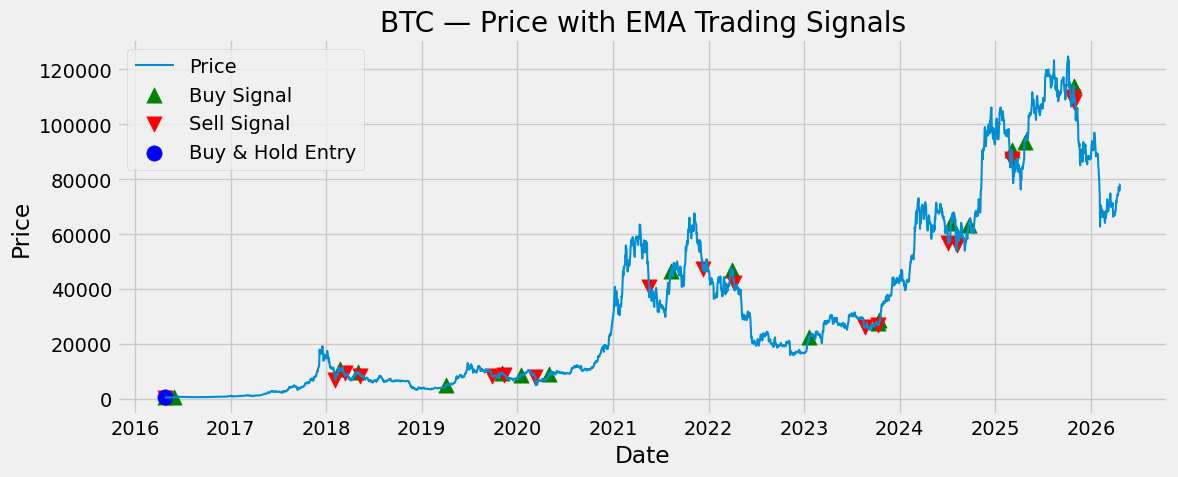

In [17]:
fast = close.ewm(span=10, adjust=False).mean()
slow = close.ewm(span=100, adjust=False).mean()

signal = (fast > slow).astype(int)

# entries / exits
buy_signals = (signal.diff() == 1)
sell_signals = (signal.diff() == -1)

for col in close.columns:
  fig, ax = plt.subplots(figsize=(12, 5))

  # Price
  ax.plot(close.index, close[col], label="Price", linewidth=1.5)

  # Buy signals
  ax.scatter(close.index[buy_signals[col]],
              close[col][buy_signals[col]],
              marker="^", color="green", label="Buy Signal", s=120)

  # Sell signals
  ax.scatter(close.index[sell_signals[col]],
              close[col][sell_signals[col]],
              marker="v", color="red", label="Sell Signal", s=120)

  # Buy & Hold entry (first day only)
  ax.scatter(close.index[0], close[col].iloc[0],
              marker="o", color="blue", label="Buy & Hold Entry", s=120)

  ax.set_title(f"{col} — Price with EMA Trading Signals")
  ax.set_xlabel("Date")
  ax.set_ylabel("Price")
  ax.legend()
  ax.grid(True)

  plt.tight_layout()
  plt.show()

#### **Grid Search Optimization of EMA Parameters**

In [18]:
returns = close.pct_change().fillna(0)

results = []

fast_range = range(5, 51, 5)
slow_range = range(20, 201, 10)

for col in close.columns:
  asset_returns = returns[col]

  best_sharpe = -np.inf
  best_params = None

  for fast in fast_range:
    for slow in slow_range:
      if fast >= slow:
        continue

      ema_fast = close[col].ewm(span=fast, adjust=False).mean()
      ema_slow = close[col].ewm(span=slow, adjust=False).mean()

      signal = (ema_fast > ema_slow).astype(int).shift(1).fillna(0)

      strat_ret = signal * asset_returns

      ann_ret = strat_ret.mean() * 252
      ann_vol = strat_ret.std() * np.sqrt(252)

      sharpe = ann_ret / ann_vol if ann_vol != 0 else 0

      if sharpe > best_sharpe:
        best_sharpe = sharpe
        best_params = (fast, slow)

  results.append({
    "asset": col,
    "best_fast": best_params[0],
    "best_slow": best_params[1],
    "best_sharpe": best_sharpe
  })

results_df = pd.DataFrame(results)
display(results_df)

,asset,best_fast,best_slow,best_sharpe
0,SPY,10,110,1.0308
1,GLD,35,50,0.8769
2,BTC,5,20,1.4334


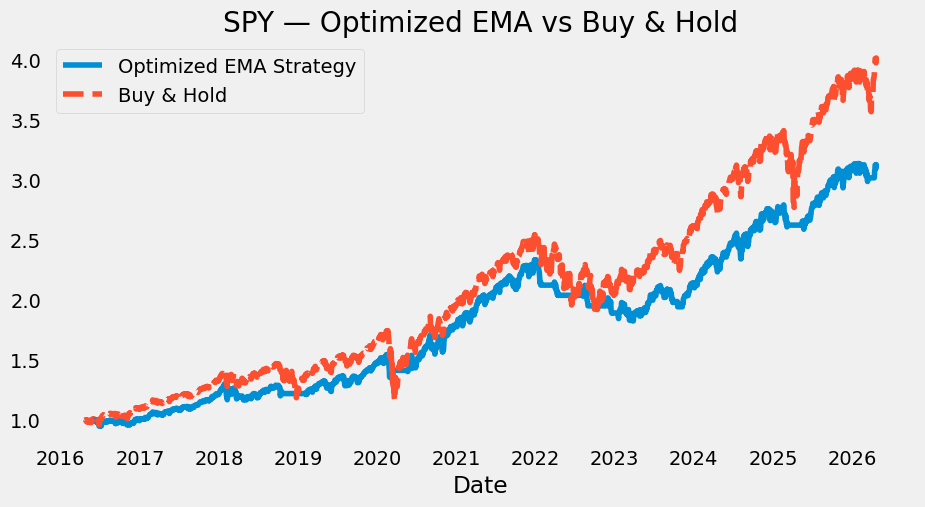

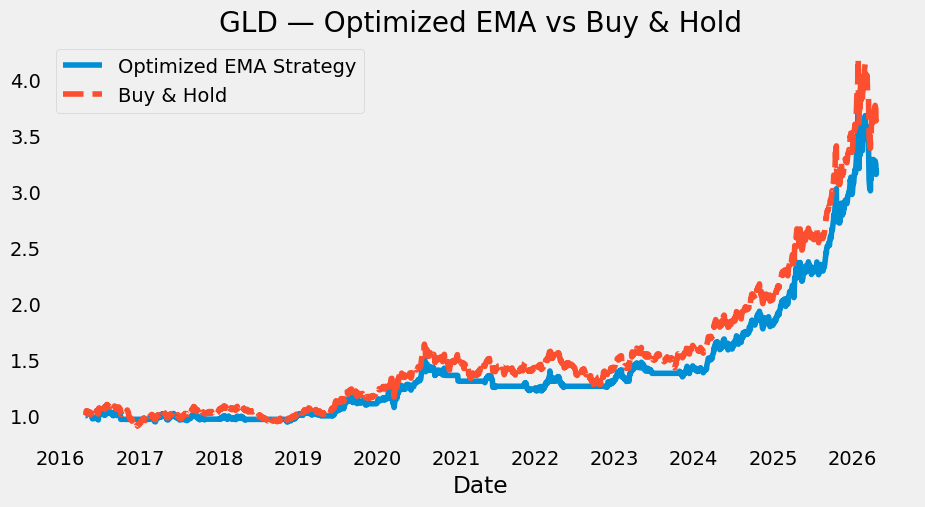

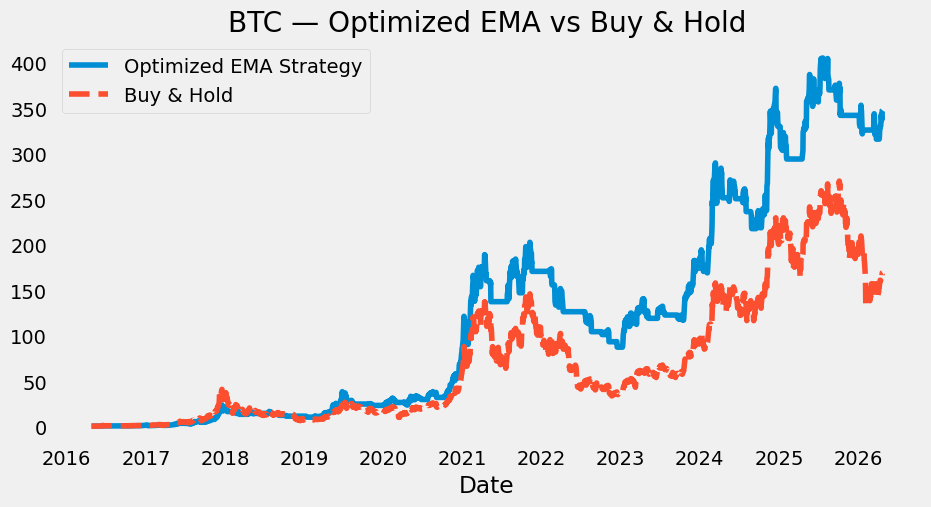

In [19]:
optimal_equity = {}

for _, row in results_df.iterrows():
  col = row["asset"]
  fast = int(row["best_fast"])
  slow = int(row["best_slow"])

  ema_fast = close[col].ewm(span=fast, adjust=False).mean()
  ema_slow = close[col].ewm(span=slow, adjust=False).mean()

  signal = (ema_fast > ema_slow).astype(int).shift(1).fillna(0)

  strat_ret = signal * returns[col]

  equity = (1 + strat_ret).cumprod()

  optimal_equity[col] = equity

for col in close.columns:
  plt.figure(figsize=(10, 5))

  plt.plot(optimal_equity[col], label="Optimized EMA Strategy")
  plt.plot((1 + returns[col]).cumprod(), "--", label="Buy & Hold")

  plt.title(f"{col} — Optimized EMA vs Buy & Hold")
  plt.legend()
  plt.grid()
  plt.xlabel('Date')

  plt.show()

#### **Out-of-Sample (OOS) Testing of the Optimized EMA Strategy**

Best Parameters:
 {'SPY': {'fast': 5, 'slow': 20, 'train_sharpe': np.float64(0.9343777246206587)}, 'GLD': {'fast': 35, 'slow': 50, 'train_sharpe': np.float64(0.614141818111703)}, 'BTC': {'fast': 10, 'slow': 40, 'train_sharpe': np.float64(1.6309395370208528)}}


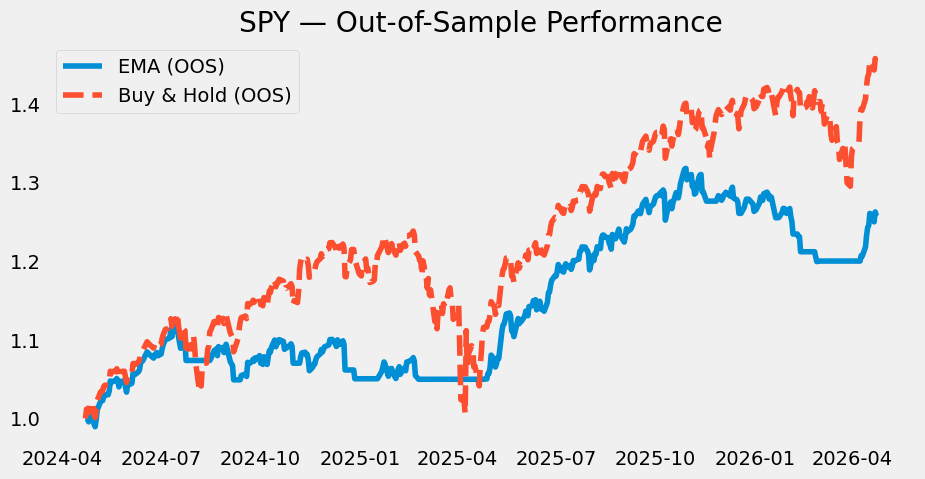

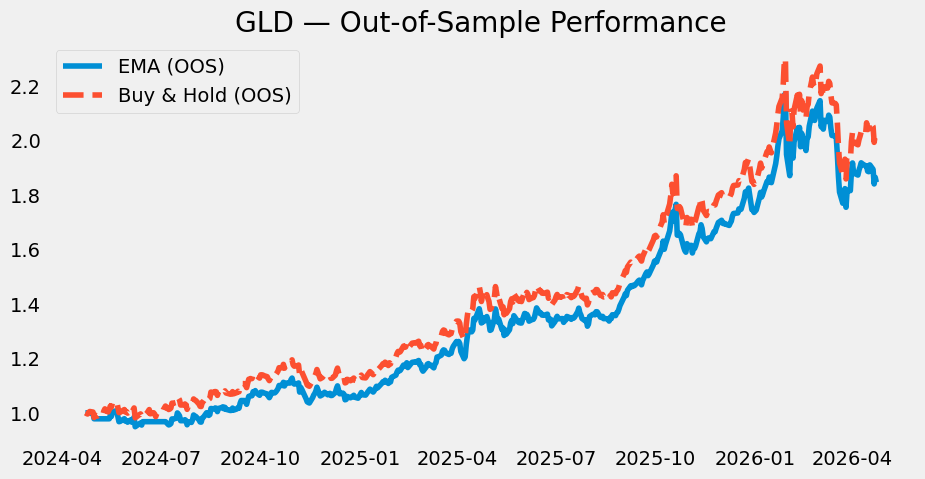

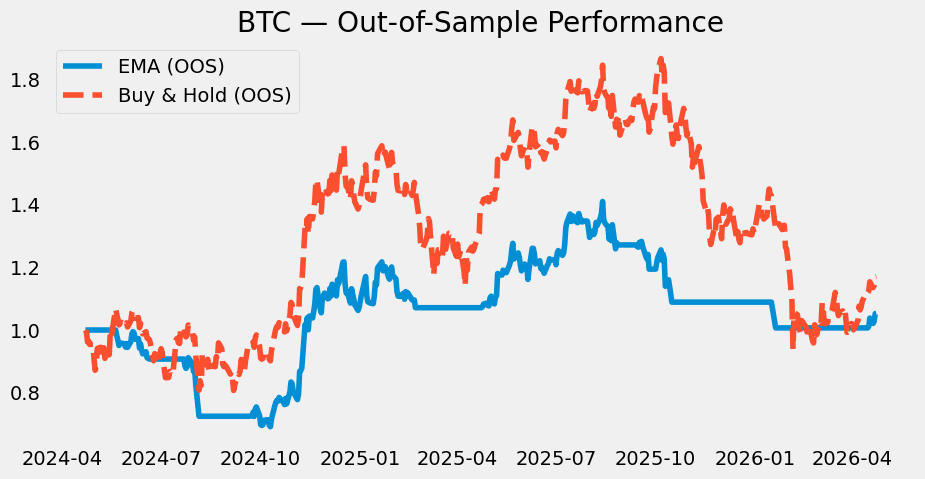

In [20]:
# 1. Train–test split

split_idx = int(len(close) * 0.8)

train_close = close.iloc[:split_idx]
test_close  = close.iloc[split_idx:]

# 2. Compute returns

train_ret = train_close.pct_change().fillna(0)
test_ret  = test_close.pct_change().fillna(0)

# 3. Parameter grid

fast_range = range(5, 51, 5)
slow_range = range(20, 201, 10)

best_params = {}

for col in close.columns:
  best_sharpe = -np.inf
  best_pair = None

  for fast in fast_range:
    for slow in slow_range:
      if fast >= slow:
        continue

      ema_fast = train_close[col].ewm(span=fast, adjust=False).mean()
      ema_slow = train_close[col].ewm(span=slow, adjust=False).mean()

      signal = (ema_fast > ema_slow).astype(int).shift(1).fillna(0)
      strat_ret = signal * train_ret[col]

      ann_ret = strat_ret.mean() * 252
      ann_vol = strat_ret.std() * np.sqrt(252)
      sharpe = ann_ret / ann_vol if ann_vol != 0 else 0

      if sharpe > best_sharpe:
        best_sharpe = sharpe
        best_pair = (fast, slow)

  best_params[col] = {
    "fast": best_pair[0],
    "slow": best_pair[1],
    "train_sharpe": best_sharpe
  }

print("Best Parameters:\n", best_params)

oos_equity = {}

for col in close.columns:
  fast = best_params[col]["fast"]
  slow = best_params[col]["slow"]

  ema_fast = test_close[col].ewm(span=fast, adjust=False).mean()
  ema_slow = test_close[col].ewm(span=slow, adjust=False).mean()

  signal = (ema_fast > ema_slow).astype(int).shift(1).fillna(0)

  strat_ret = signal * test_ret[col]

  equity = (1 + strat_ret).cumprod()
  oos_equity[col] = equity

for col in close.columns:
  plt.figure(figsize=(10,5))

  bh = (1 + test_ret[col]).cumprod()

  plt.plot(oos_equity[col], label="EMA (OOS)")
  plt.plot(bh, "--", label="Buy & Hold (OOS)")

  plt.title(f"{col} — Out-of-Sample Performance")
  plt.legend()
  plt.grid()

  plt.show()

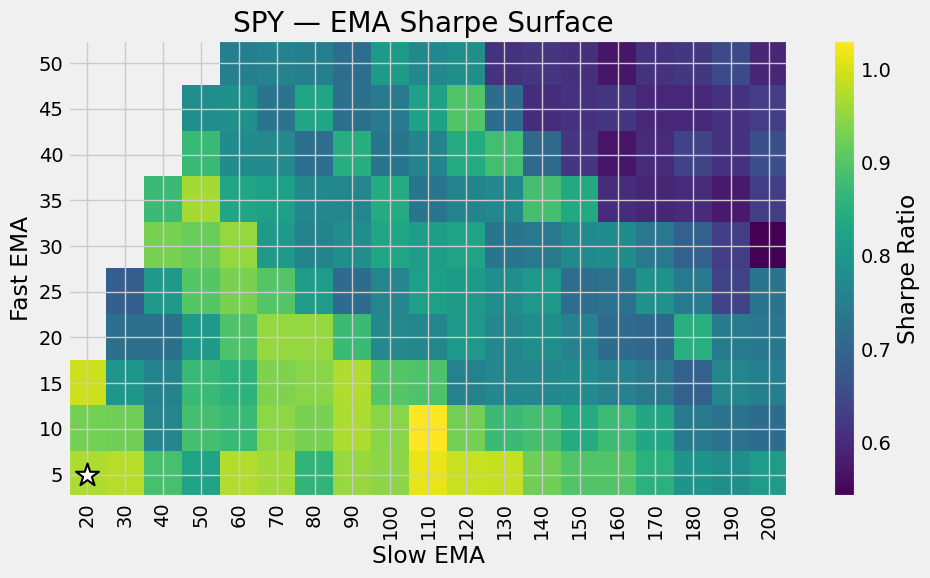

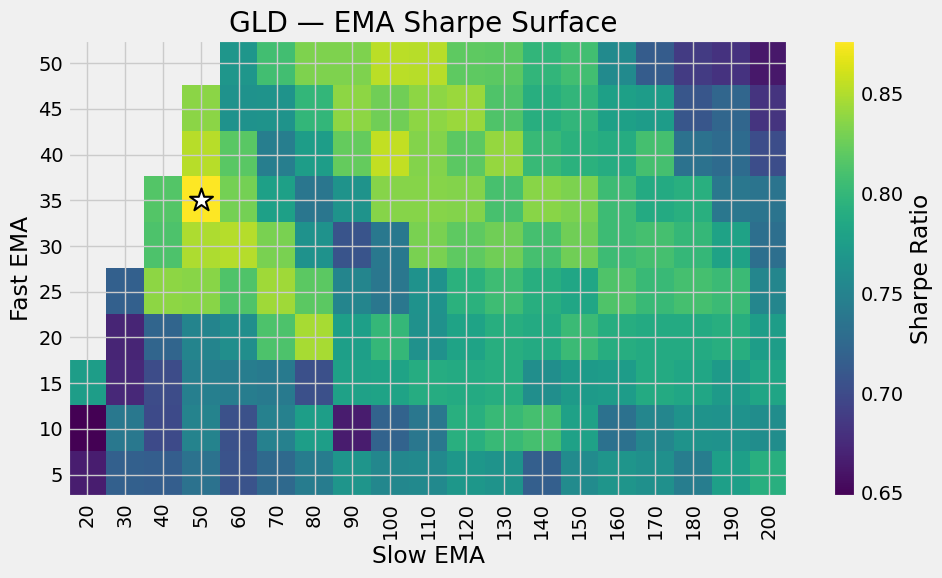

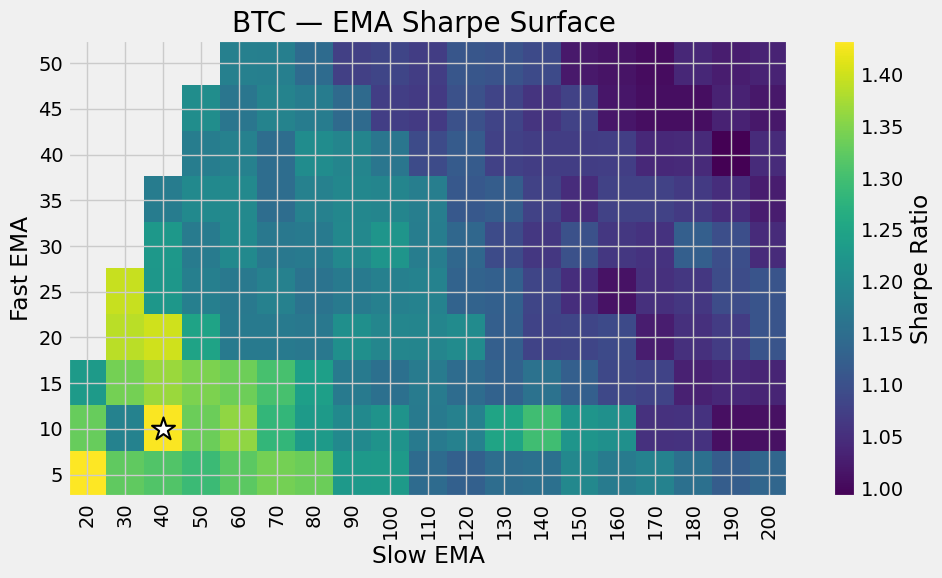

In [21]:
def compute_sharpe_grid(asset_name):
    """Helper to generate Sharpe Ratio grid for heatmap."""
    f_range = range(5, 51, 5)
    s_range = range(20, 201, 10)
    grid_data = []

    asset_close = close[asset_name]
    asset_ret = returns[asset_name]

    for f in f_range:
        for s in s_range:
            if f >= s:
                grid_data.append({'fast': f, 'slow': s, 'sharpe': np.nan})
                continue

            e_fast = asset_close.ewm(span=f, adjust=False).mean()
            e_slow = asset_close.ewm(span=s, adjust=False).mean()
            sig = (e_fast > e_slow).astype(int).shift(1).fillna(0)
            s_ret = sig * asset_ret

            a_ret = s_ret.mean() * 252
            a_vol = s_ret.std() * np.sqrt(252)
            sr = a_ret / a_vol if a_vol != 0 else 0
            grid_data.append({'fast': f, 'slow': s, 'sharpe': sr})

    df_grid = pd.DataFrame(grid_data)
    return df_grid.pivot(index='fast', columns='slow', values='sharpe')

for asset in close.columns:
  grid = compute_sharpe_grid(asset)

  bf = best_params[asset]["fast"]
  bs = best_params[asset]["slow"]

  plt.figure(figsize=(10, 6))

  # --- heatmap ---
  plt.imshow(grid.values, aspect="auto", origin="lower")
  plt.colorbar(label="Sharpe Ratio")

  # --- axis labels ---
  plt.xticks(
    ticks=np.arange(len(grid.columns)),
    labels=grid.columns,
    rotation=90
  )

  plt.yticks(
    ticks=np.arange(len(grid.index)),
    labels=grid.index
  )

  # --- map (fast, slow) → grid coordinates ---
  y = list(grid.index).index(bf)
  x = list(grid.columns).index(bs)

  # best solution marker
  plt.scatter(
    x, y,
    marker="*",
    s=300,
    color="white",
    edgecolors="black",
    linewidth=1.5
  )

  plt.title(f"{asset} — EMA Sharpe Surface ")
  plt.xlabel("Slow EMA")
  plt.ylabel("Fast EMA")

  plt.tight_layout()
  plt.show()

In [22]:
oos_equity = {}
oos_returns = {}

for col in close.columns:
  fast = best_params[col]["fast"]
  slow = best_params[col]["slow"]

  ema_fast = test_close[col].ewm(span=fast, adjust=False).mean()
  ema_slow = test_close[col].ewm(span=slow, adjust=False).mean()

  signal = (ema_fast > ema_slow).astype(int).shift(1).fillna(0)

  strat_ret = signal * test_ret[col]
  oos_returns[col] = strat_ret

  equity = (1 + strat_ret).cumprod()
  oos_equity[col] = equity

# Convert to DataFrames
oos_equity = pd.DataFrame(oos_equity)
oos_returns = pd.DataFrame(oos_returns)

# ---- Performance Metrics ---- #

def performance_stats(returns, equity, freq=252):
  stats = {}

  total_return = equity.iloc[-1] - 1
  ann_return = (equity.iloc[-1])**(freq / len(equity)) - 1
  ann_vol = returns.std() * np.sqrt(freq)

  sharpe = ann_return / ann_vol if ann_vol != 0 else np.nan

  # Drawdown
  running_max = equity.cummax()
  drawdown = (equity - running_max) / running_max
  max_dd = drawdown.min()

  stats["Total Return"] = total_return
  stats["Annual Return"] = ann_return
  stats["Annual Vol"] = ann_vol
  stats["Sharpe"] = sharpe
  stats["Max Drawdown"] = max_dd

  return stats

# Compute stats per asset
results = {}

for col in oos_equity.columns:
  results[col] = performance_stats(oos_returns[col], oos_equity[col])

results_df = pd.DataFrame(results).T

display(results_df)

,Total Return,Annual Return,Annual Vol,Sharpe,Max Drawdown
SPY,0.2579,0.1218,0.0965,1.2616,-0.0899
GLD,0.8463,0.3596,0.2231,1.6120,-0.1921
BTC,0.0534,0.0264,0.2978,0.0887,-0.3086


#### **Backtesting the Optimized EMA Strategy with VectorBT**

In [23]:
pf_dict = {}

for asset in close.columns:
  fast = best_params[asset]["fast"]
  slow = best_params[asset]["slow"]

  # --- EMAs ---
  ema_fast = close[asset].ewm(span=fast, adjust=False).mean()
  ema_slow = close[asset].ewm(span=slow, adjust=False).mean()

  # --- signals ---
  entries = ema_fast > ema_slow
  exits = ema_fast < ema_slow

  # --- independent backtest ---
  pf = vbt.Portfolio.from_signals(
    close[asset],
    entries,
    exits,
    init_cash=10000,
    fees=0.001,
    freq="1D"
  )

  pf_dict[asset] = pf

for asset, pf in pf_dict.items():
  print("\n======================")
  print(asset)
  print("======================")
  print(pf.stats())


SPY
Start                                2016-04-25 00:00:00
End                                  2026-04-23 00:00:00
Period                                2514 days 00:00:00
Start Value                                   10000.0000
End Value                                     23213.5857
Total Return [%]                                132.1359
Benchmark Return [%]                            299.7283
Max Gross Exposure [%]                          100.0000
Total Fees Paid                                1875.9472
Max Drawdown [%]                                 16.7584
Max Drawdown Duration                  411 days 00:00:00
Total Trades                                          65
Total Closed Trades                                   64
Total Open Trades                                      1
Open Trade PnL                                 1040.8020
Win Rate [%]                                     40.6250
Best Trade [%]                                   21.3622
Worst Trade [%]           

In [24]:
pf_dict["SPY"].plot().show()

In [25]:
pf_dict["GLD"].plot().show()

In [26]:
pf_dict["BTC"].plot().show()

In [27]:
for asset, pf in pf_dict.items():
  fig = pf.trades.plot()
  fig.update_layout(
    title=f"{asset} — Trades",
    showlegend=False
  )

  fig.show()

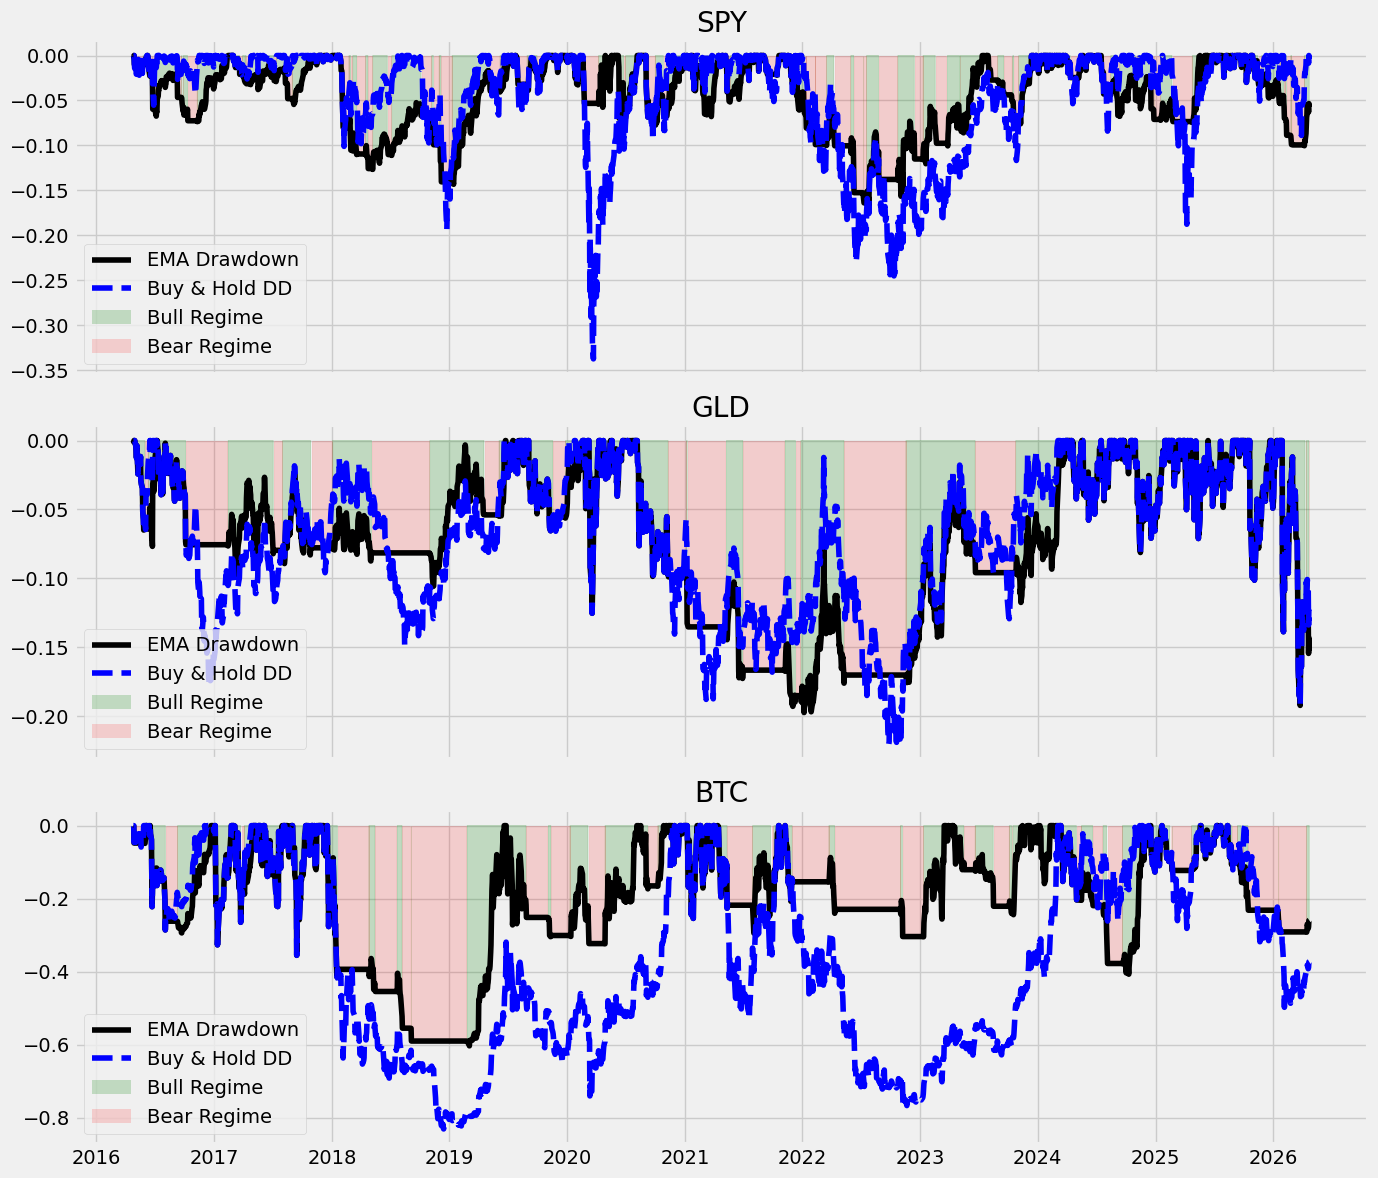

In [28]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

for i, asset in enumerate(close.columns):
  ax = axes[i]

  pf = pf_dict[asset]

  fast = best_params[asset]["fast"]
  slow = best_params[asset]["slow"]

  ema_fast = close[asset].ewm(span=fast, adjust=False).mean()
  ema_slow = close[asset].ewm(span=slow, adjust=False).mean()

  regime = ema_fast > ema_slow

  strat_equity = pf.value()
  strat_dd = strat_equity / strat_equity.cummax() - 1

  bh_equity = close[asset] / close[asset].iloc[0]
  bh_dd = bh_equity / bh_equity.cummax() - 1

  # --- plots ---
  ax.plot(strat_dd.index, strat_dd, color="black", label="EMA Drawdown")
  ax.plot(bh_dd.index, bh_dd, "--", color="blue", label="Buy & Hold DD")

  ax.fill_between(
    strat_dd.index,
    strat_dd.values,
    0,
    where=regime.values,
    color="green",
    alpha=0.2
  )

  ax.fill_between(
    strat_dd.index,
    strat_dd.values,
    0,
    where=(~regime).values,
    color="red",
    alpha=0.15
  )

  ax.set_title(asset)
  ax.grid(True)

  # legend only once per axis (safe)
  handles, labels = ax.get_legend_handles_labels()

  regime_legend = [
    Patch(facecolor="green", alpha=0.2, label="Bull Regime"),
    Patch(facecolor="red", alpha=0.15, label="Bear Regime")
  ]

  ax.legend(handles=handles + regime_legend)

plt.tight_layout()
plt.show()